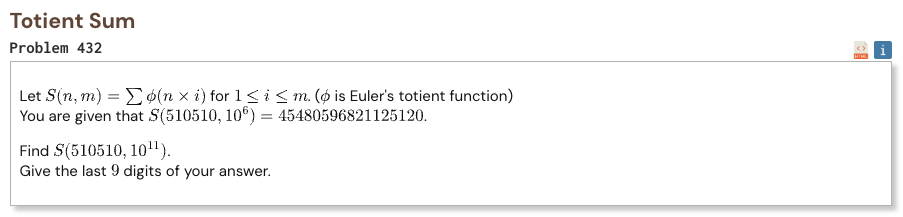

## Initial approach

-   factor 510510 into the primes 2, 3, 5, 7, 11, 13 and 17
-   remove these prime factors one at a time using a recurrence for the totient sum
-   this reduces the whole problem to finding prefix sums of Euler totients
-   precompute totient prefix sums up to a manageable limit with a sieve
-   for larger values use the divisor sum identity and memoization instead of calculating every totient
-   group equal integer division results together so each recursive calculation skips large ranges
-   keep every calculation modulo one billion because only the last nine digits are needed

In [1]:
%%time

from array import array

MOD = 10**9
N = 10**11
LIMIT = 22000000

phi = array("I", [0]) * (LIMIT + 1)
primes = array("I")

phi[1] = 1

for i in range(2, LIMIT + 1):
    if phi[i] == 0:
        phi[i] = i - 1
        primes.append(i)

    for p in primes:
        x = i * p

        if x > LIMIT:
            break

        if i % p == 0:
            phi[x] = phi[i] * p
            break

        phi[x] = phi[i] * (p - 1)

total = 0

for i in range(1, LIMIT + 1):
    total = (total + phi[i]) % MOD
    phi[i] = total

memo_phi_sum = {}

def phi_sum(n):
    if n <= LIMIT:
        return phi[n]

    if n in memo_phi_sum:
        return memo_phi_sum[n]

    result = n * (n + 1) // 2
    result %= MOD

    left = 2

    while left <= n:
        q = n // left
        right = n // q

        result -= (right - left + 1) * phi_sum(q)
        result %= MOD

        left = right + 1

    memo_phi_sum[n] = result
    return result

factors = [2, 3, 5, 7, 11, 13, 17]
memo_s = {}

def S(index, m):
    if m == 0:
        return 0

    if index == len(factors):
        return phi_sum(m)

    key = (index, m)

    if key in memo_s:
        return memo_s[key]

    p = factors[index]

    result = (p - 1) * S(index + 1, m)
    result += S(index, m // p)
    result %= MOD

    memo_s[key] = result
    return result

result = S(0, N)

print("Result:", result)

Result: 754862080
CPU times: user 19.7 s, sys: 74.4 ms, total: 19.7 s
Wall time: 20 s
